<a href="https://colab.research.google.com/github/aabelatilaw/House-Price-Prediction-using-Machine-Learning/blob/main/house_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# House Price Prediction using Machine Learning

This notebook walks through the process of building a house price prediction model. It covers:
1. Loading Data
2. Initial Data Inspection
3. Exploratory Data Analysis (EDA)
4. Preprocessing (Missing Values, Encoding, Scaling)
5. Outlier Removal (Example)
6. Redundant Feature Removal (High Correlation)
7. Train/Test Split
8. Model Training (Linear Regression, Ridge, Random Forest)
9. Model Evaluation
10. Results Summary

## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings

# Configure settings
warnings.filterwarnings('ignore') # Ignore warnings for cleaner output
sns.set_style('whitegrid') # Set plot style
%matplotlib inline
# Ensures plots are displayed inline in the notebook

## 2. Load Data

In [ ]:
# Construct the raw GitHub URL for the Excel file
github_url = 'https://github.com/aabelatilaw/House-Price-Prediction-using-Machine-Learning/raw/main/HousePricePrediction.xlsx'

try:
    df = pd.read_excel(github_url)
    print("Data loaded successfully.")
    print(f"Dataset shape: {df.shape}")
except Exception as e:
    print(f"Error loading data: {e}")
    print("Please ensure the URL is correct and accessible.")
    # In a notebook, we might not want to exit(), but raise the error or stop
    raise e

Data loaded successfully.
Dataset shape: (2919, 13)


## 3. Initial Data Inspection

In [ ]:
# remove missing values

df= df.dropna()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1460 entries, 0 to 1459
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            1460 non-null   int64  
 1   MSSubClass    1460 non-null   int64  
 2   MSZoning      1460 non-null   object 
 3   LotArea       1460 non-null   int64  
 4   LotConfig     1460 non-null   object 
 5   BldgType      1460 non-null   object 
 6   OverallCond   1460 non-null   int64  
 7   YearBuilt     1460 non-null   int64  
 8   YearRemodAdd  1460 non-null   int64  
 9   Exterior1st   1460 non-null   object 
 10  BsmtFinSF2    1460 non-null   float64
 11  TotalBsmtSF   1460 non-null   float64
 12  SalePrice     1460 non-null   float64
dtypes: float64(3), int64(6), object(4)
memory usage: 159.7+ KB


In [ ]:
print("First 5 rows:")
display(df.head())

First 5 rows:


,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0


In [ ]:
print("\nData Info:")
df.info()


Data Info:
<class 'pandas.core.frame.DataFrame'>
Index: 1460 entries, 0 to 1459
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            1460 non-null   int64  
 1   MSSubClass    1460 non-null   int64  
 2   MSZoning      1460 non-null   object 
 3   LotArea       1460 non-null   int64  
 4   LotConfig     1460 non-null   object 
 5   BldgType      1460 non-null   object 
 6   OverallCond   1460 non-null   int64  
 7   YearBuilt     1460 non-null   int64  
 8   YearRemodAdd  1460 non-null   int64  
 9   Exterior1st   1460 non-null   object 
 10  BsmtFinSF2    1460 non-null   float64
 11  TotalBsmtSF   1460 non-null   float64
 12  SalePrice     1460 non-null   float64
dtypes: float64(3), int64(6), object(4)
memory usage: 159.7+ KB


In [ ]:
print("\nDescriptive Statistics (Numerical Features):")
display(df.describe())


Descriptive Statistics (Numerical Features):


,Id,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,729.500000,56.897260,10516.828082,5.575342,1971.267808,1984.865753,46.549315,1057.429452,180921.195890
std,421.610009,42.300571,9981.264932,1.112799,30.202904,20.645407,161.319273,438.705324,79442.502883
min,0.000000,20.000000,1300.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,34900.000000
25%,364.750000,20.000000,7553.500000,5.000000,1954.000000,1967.000000,0.000000,795.750000,129975.000000
50%,729.500000,50.000000,9478.500000,5.000000,1973.000000,1994.000000,0.000000,991.500000,163000.000000
75%,1094.250000,70.000000,11601.500000,6.000000,2000.000000,2004.000000,0.000000,1298.250000,214000.000000
max,1459.000000,190.000000,215245.000000,9.000000,2010.000000,2010.000000,1474.000000,6110.000000,755000.000000


In [ ]:
print("\nDescriptive Statistics (Categorical Features):")
display(df.describe(include='object'))


Descriptive Statistics (Categorical Features):


,MSZoning,LotConfig,BldgType,Exterior1st
count,1460,1460,1460,1460
unique,5,5,5,15
top,RL,Inside,1Fam,VinylSd
freq,1151,1052,1220,515


In [ ]:
# Drop the 'Id' column as it's just an identifier
if 'Id' in df.columns:
    df = df.drop('Id', axis=1)
    print("\n'Id' column dropped.")
else:
    print("\n'Id' column not found.")


'Id' column dropped.


In [ ]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())


# Check for duplicates
print(f"\nNumber of duplicates: {df.duplicated().sum()}")

# Remove duplicates if any
df.drop_duplicates(inplace=True)

Missing values per column:
MSSubClass      0
MSZoning        0
LotArea         0
LotConfig       0
BldgType        0
OverallCond     0
YearBuilt       0
YearRemodAdd    0
Exterior1st     0
BsmtFinSF2      0
TotalBsmtSF     0
SalePrice       0
dtype: int64

Number of duplicates: 0


In [ ]:
# Check for duplicate rows
print(f"Number of duplicate rows: {df.duplicated().sum()}")

# If you want to see the duplicate rows before removal
duplicates = df[df.duplicated(keep=False)]  # keep=False marks all duplicates
if not duplicates.empty:
    print("\nDuplicate rows found:")
    display(duplicates.sort_values(by=df.columns.tolist()))

Number of duplicate rows: 0


In [ ]:
# Remove duplicates (keeping the first occurrence)
df_clean = df.drop_duplicates()

print(f"\nShape after removing duplicates: {df_clean.shape}")
print(f"Rows removed: {len(df) - len(df_clean)}")


Shape after removing duplicates: (1460, 12)
Rows removed: 0



Missing values per column:
Series([], dtype: int64)


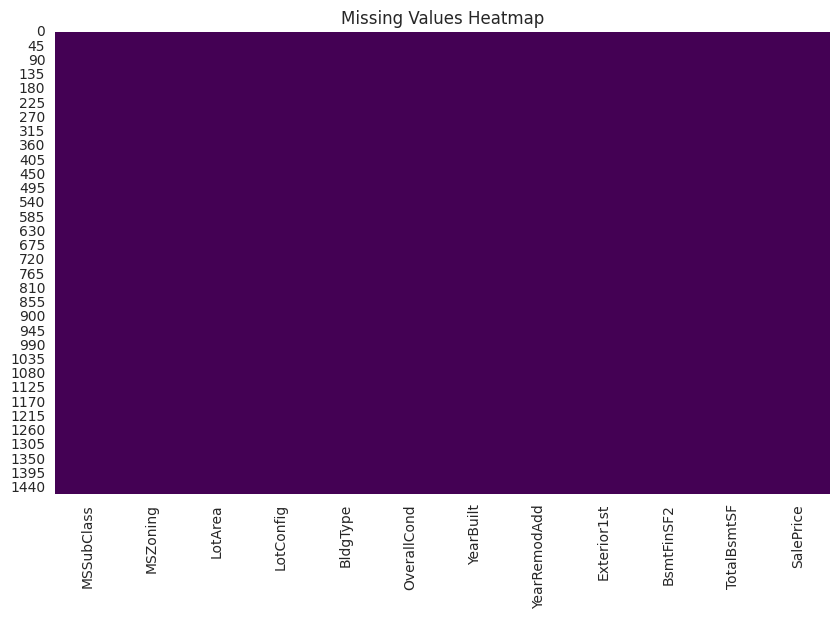

In [ ]:
# Check for missing values
missing_values = df_clean.isnull().sum()
print("\nMissing values per column:")
print(missing_values[missing_values > 0])

# Visualize missing values
plt.figure(figsize=(10, 6))
sns.heatmap(df_clean.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

## 4. Exploratory Data Analysis (EDA)

### 4.1 Analyze Target Variable (SalePrice)

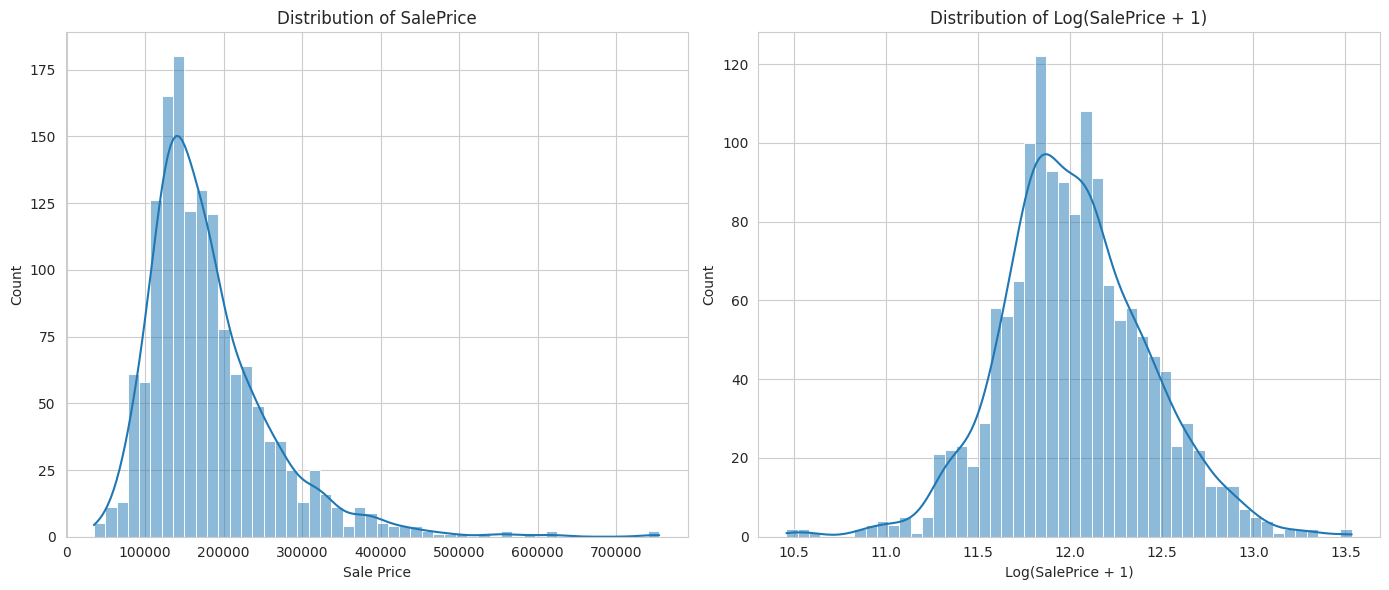


Skewness of SalePrice: 1.88
Skewness after Log Transform: 0.12


In [ ]:
TARGET = 'SalePrice'

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(df[TARGET], kde=True, bins=50)
plt.title('Distribution of SalePrice')
plt.xlabel('Sale Price')

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df[TARGET]), kde=True, bins=50)
plt.title('Distribution of Log(SalePrice + 1)')
plt.xlabel('Log(SalePrice + 1)')

plt.tight_layout()
plt.show()

print(f"\nSkewness of SalePrice: {df[TARGET].skew():.2f}")
# Apply log transformation to the target variable to reduce skewness
df[TARGET] = np.log1p(df[TARGET])
print(f"Skewness after Log Transform: {df[TARGET].skew():.2f}")

The SalePrice is right-skewed. Applying a log transformation makes its distribution closer to normal, which often benefits linear models.

### 4.2 Correlation Analysis (Numerical Features)

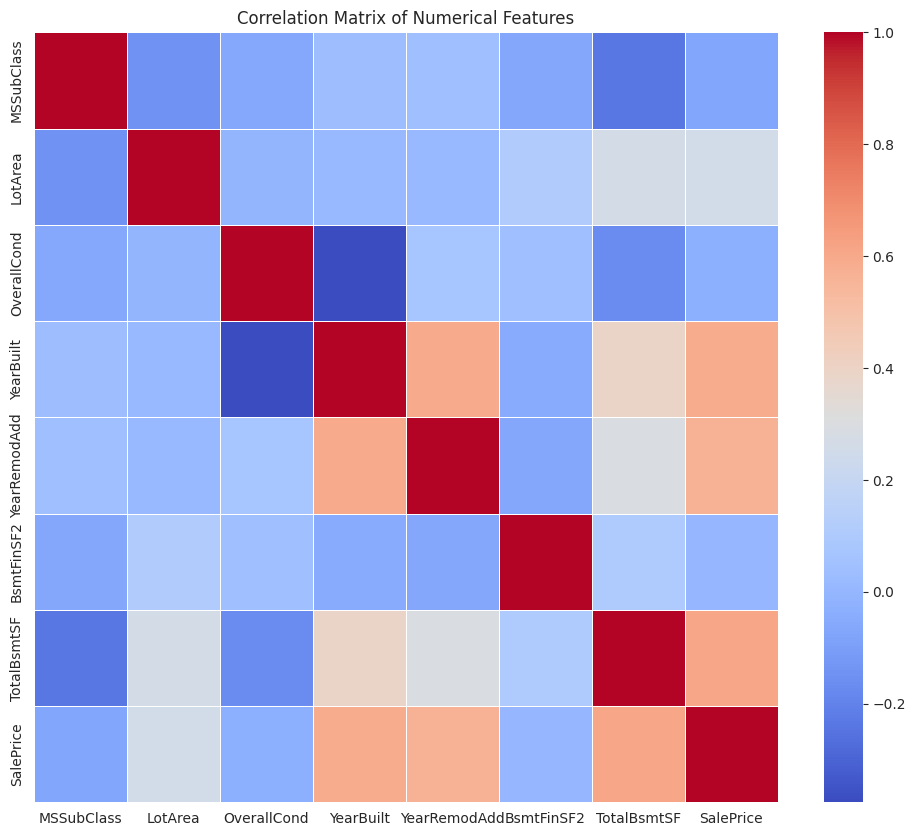


Top 10 Features Correlated with Log(SalePrice):
SalePrice       1.000000
TotalBsmtSF     0.612134
YearBuilt       0.586570
YearRemodAdd    0.565608
LotArea         0.257320
BsmtFinSF2      0.004832
OverallCond    -0.036868
MSSubClass     -0.073959
Name: SalePrice, dtype: float64


In [ ]:
# Select only numeric types for correlation calculation
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, cmap='coolwarm', fmt=".1f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# Show features most correlated with SalePrice (log-transformed)
print("\nTop 10 Features Correlated with Log(SalePrice):")
top_corr = correlation_matrix[TARGET].sort_values(ascending=False).head(11)
print(top_corr)

Features like `OverallQual`, `GrLivArea`, `GarageCars`, `GarageArea`, `TotalBsmtSF`, and `1stFlrSF` show strong positive correlation with the (log-transformed) `SalePrice`.

### 4.3 Visualize Relationships: Top Features vs Log(SalePrice)

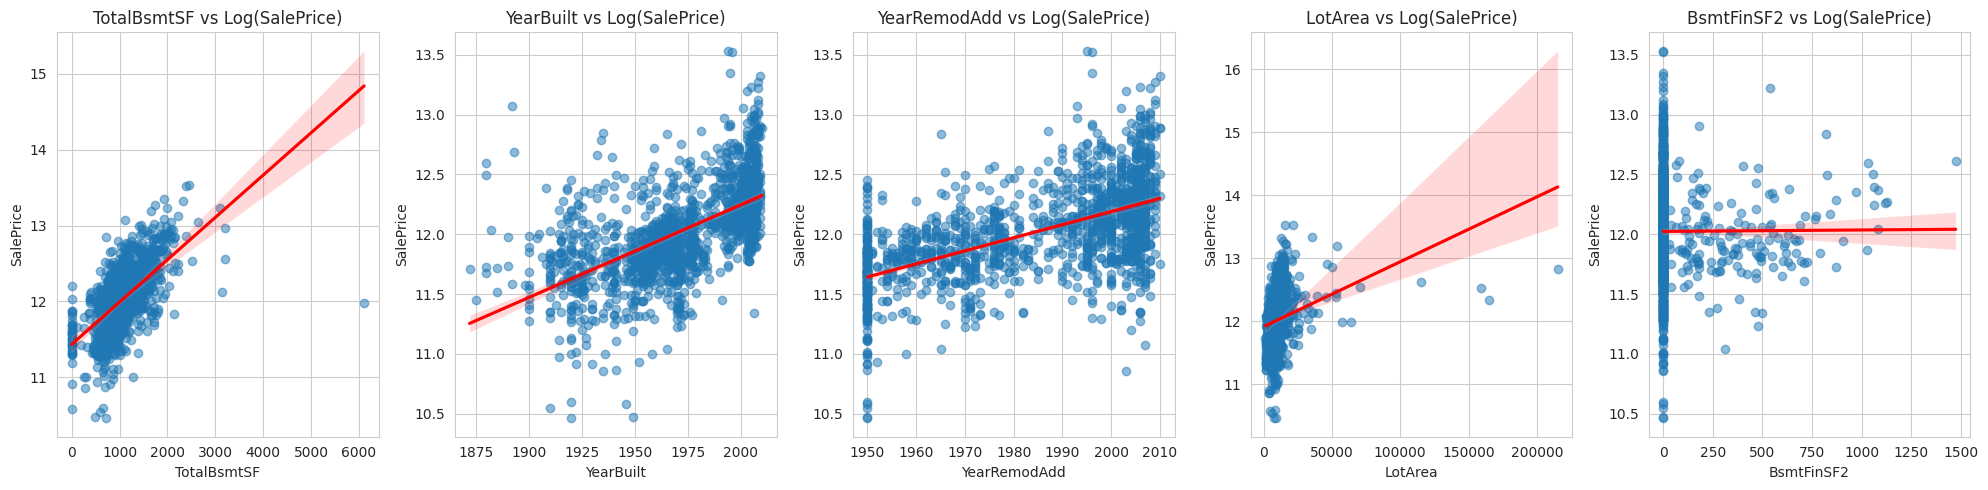

In [ ]:
top_corr_features = top_corr.index[1:6] # Get top 5 predictors (excluding SalePrice itself)

plt.figure(figsize=(20, 5))
for i, feature in enumerate(top_corr_features):
    plt.subplot(1, len(top_corr_features), i + 1)
    sns.regplot(data=df, x=feature, y=TARGET, line_kws={"color":"red"}, scatter_kws={'alpha':0.5})
    plt.title(f'{feature} vs Log(SalePrice)')
plt.tight_layout()
plt.show()

### 4.4 Analyze Key Categorical Features

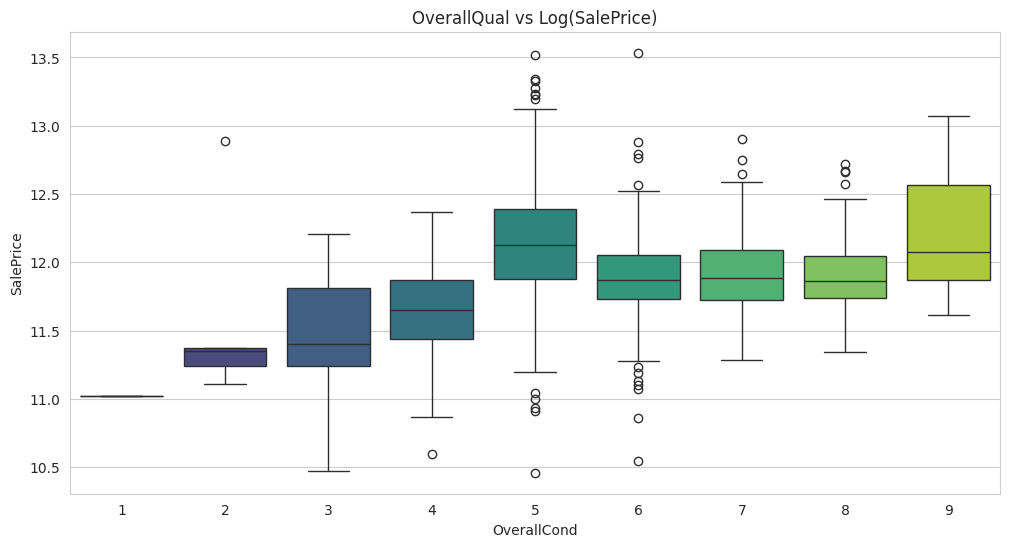

In [ ]:
# Example: Overall Quality
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='OverallCond', y=TARGET, palette='viridis')
plt.title('OverallQual vs Log(SalePrice)')
plt.show()

# Example: Neighborhood (show top N neighborhoods by median price)
if 'Neighborhood' in df.columns:
    plt.figure(figsize=(14, 8))
    # Order neighborhoods by median log price
    order = df.groupby('Neighborhood')[TARGET].median().sort_values().index
    sns.boxplot(data=df, x=TARGET, y='Neighborhood', order=order, palette='coolwarm')
    plt.title('Log(SalePrice) Distribution by Neighborhood')
    plt.xlabel('Log(SalePrice + 1)')
    plt.ylabel('Neighborhood')
    plt.show()

## 5. Preprocessing

### 5.1 Handle Missing Values

In [ ]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_percent = (missing_values / len(df)) * 100
missing_data = pd.concat([missing_values, missing_percent], axis=1, keys=['Total', 'Percent'])

print("Missing Values (%):")
display(missing_data[missing_data['Total'] > 0].head(20)) # Show top 20 missing

# Define columns to drop based on high percentage of missing values (e.g., > 80%)
missing_threshold = 80
cols_to_drop_missing = missing_data[missing_data['Percent'] > missing_threshold].index
df = df.drop(cols_to_drop_missing, axis=1)
print(f"\nDropped columns due to high missing values (> {missing_threshold}%): {list(cols_to_drop_missing)}")
print(f"Data shape after dropping high-missing columns: {df.shape}")

Missing Values (%):


,Total,Percent



Dropped columns due to high missing values (> 80%): []
Data shape after dropping high-missing columns: (1460, 12)


Columns like `PoolQC`, `MiscFeature`, `Alley`, `Fence` have a very high percentage of missing values and have been dropped. Other missing values will be imputed.

### 5.2 Separate Features and Target, Identify Feature Types

In [ ]:
X = df.drop(TARGET, axis=1)
y = df[TARGET] # y is already log-transformed

# Identify numerical and categorical features *after* dropping columns
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

print(f"Target variable: {TARGET}")
print(f"\nNumerical features ({len(numerical_features)}): {numerical_features}")
print(f"\nCategorical features ({len(categorical_features)}): {categorical_features}")

Target variable: SalePrice

Numerical features (7): ['MSSubClass', 'LotArea', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'BsmtFinSF2', 'TotalBsmtSF']

Categorical features (4): ['MSZoning', 'LotConfig', 'BldgType', 'Exterior1st']


### 5.3 Create Preprocessing Pipelines

In [ ]:
# Pipeline for numerical features: Impute with median, then scale
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline for categorical features: Impute with most frequent, then one-hot encode
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine pipelines using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_features),
        ('cat', categorical_pipeline, categorical_features)
    ],
    remainder='passthrough' # Keep other columns if any (should be none here)
)

### 5.4 Apply Preprocessing

**Note:** For simplicity in demonstrating outlier/redundancy removal next, we apply `fit_transform` to the entire dataset `X` here. In a strict workflow aiming for generalization, you should **split the data first**, then `fit_transform` the `preprocessor` on the *training set* (`X_train`) and only `transform` the *test set* (`X_test`) to avoid data leakage.

In [ ]:
# Apply the preprocessing steps
# Using fit_transform before split for demonstration purposes (see note above)
X_processed_np = preprocessor.fit_transform(X)

# Get feature names after one-hot encoding (important!)
feature_names_out = preprocessor.get_feature_names_out()

# Convert the processed NumPy array back to a DataFrame
X_processed = pd.DataFrame(X_processed_np, columns=feature_names_out, index=X.index)

print("Preprocessing complete. Data imputed and scaled/encoded.")
print(f"Shape after preprocessing: {X_processed.shape}")
print("First 5 rows of processed data:")
display(X_processed.head())

Preprocessing complete. Data imputed and scaled/encoded.
Shape after preprocessing: (1460, 37)
First 5 rows of processed data:


,num__MSSubClass,num__LotArea,num__OverallCond,num__YearBuilt,num__YearRemodAdd,num__BsmtFinSF2,num__TotalBsmtSF,cat__MSZoning_C (all),cat__MSZoning_FV,cat__MSZoning_RH,...,cat__Exterior1st_CemntBd,cat__Exterior1st_HdBoard,cat__Exterior1st_ImStucc,cat__Exterior1st_MetalSd,cat__Exterior1st_Plywood,cat__Exterior1st_Stone,cat__Exterior1st_Stucco,cat__Exterior1st_VinylSd,cat__Exterior1st_Wd Sdng,cat__Exterior1st_WdShing
0,0.073375,-0.207142,-0.517200,1.050994,0.878668,-0.288653,-0.459303,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,-0.872563,-0.091886,2.179628,0.156734,-0.429577,-0.288653,0.466465,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.073375,0.073480,-0.517200,0.984752,0.830215,-0.288653,-0.313369,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.309859,-0.096897,-0.517200,-1.863632,-0.720298,-0.288653,-0.687324,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.073375,0.375148,-0.517200,0.951632,0.733308,-0.288653,0.199680,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## 6. Remove Outliers (Example using IQR)

Outlier removal is subjective and domain-dependent. Here's an example removing potential outliers based on `GrLivArea` (Ground Living Area), a strong predictor. We use the original `GrLivArea` values from `X` for IQR calculation before they were scaled.

In [ ]:
print("--- Outlier Removal (Example based on GrLivArea) ---")

grlivarea_col_orig = 'GrLivArea'

if grlivarea_col_orig in X.columns: # Check if the column exists in the original X
    Q1 = X[grlivarea_col_orig].quantile(0.25)
    Q3 = X[grlivarea_col_orig].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    print(f"GrLivArea - Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
    print(f"GrLivArea - Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")

    # Find indices of outliers in the original data X based on GrLivArea
    outlier_indices = X[(X[grlivarea_col_orig] < lower_bound) | (X[grlivarea_col_orig] > upper_bound)].index
    print(f"\nNumber of outliers detected based on GrLivArea: {len(outlier_indices)}")

    if len(outlier_indices) > 0:
        # Remove outliers from both X_processed and y using the identified indices
        X_processed_before_outliers = X_processed.shape[0]
        y_before_outliers = y.shape[0]

        X_processed = X_processed.drop(outlier_indices, axis=0)
        y = y.drop(outlier_indices, axis=0) # y still holds the log-transformed SalePrice

        print(f"Removed {len(outlier_indices)} rows.")
        print(f"Data shape after removing GrLivArea outliers: X={X_processed.shape}, y={y.shape}")

        # Verify removal
        assert X_processed.shape[0] == X_processed_before_outliers - len(outlier_indices)
        assert y.shape[0] == y_before_outliers - len(outlier_indices)
    else:
        print("No outliers found based on GrLivArea and the 1.5*IQR rule.")
else:
    print(f"'{grlivarea_col_orig}' not found in original columns. Skipping outlier removal step.")

--- Outlier Removal (Example based on GrLivArea) ---
'GrLivArea' not found in original columns. Skipping outlier removal step.


## 7. Remove Redundant Features (High Correlation)

Check for multicollinearity among the processed numerical features. If two features are very highly correlated (e.g., > 0.95), one can be removed as it doesn't add much unique information.

In [ ]:
print("--- Redundant Feature Removal (High Correlation) ---")

# Calculate correlation matrix on the processed numerical data
# Identify columns that came from the numerical pipeline
processed_num_cols = [col for col in X_processed.columns if col.startswith('num__')]

if processed_num_cols:
    corr_matrix_processed = X_processed[processed_num_cols].corr().abs()

    # Create a mask to only consider the upper triangle (avoid duplicates)
    upper_tri = corr_matrix_processed.where(np.triu(np.ones(corr_matrix_processed.shape), k=1).astype(bool))

    # Find features with correlation greater than a threshold
    corr_threshold = 0.95
    to_drop_corr = [column for column in upper_tri.columns if any(upper_tri[column] > corr_threshold)]

    print(f"Features to potentially drop due to high correlation (> {corr_threshold}): {to_drop_corr}")

    if to_drop_corr:
        # Drop these highly correlated features
        X_processed = X_processed.drop(to_drop_corr, axis=1)
        print(f"\nDropped {len(to_drop_corr)} highly correlated features.")
        print(f"Shape after dropping highly correlated features: {X_processed.shape}")
    else:
        print("\nNo features found with correlation above the threshold.")
else:
    print("No numerical features found in processed data to check for correlation.")

--- Redundant Feature Removal (High Correlation) ---
Features to potentially drop due to high correlation (> 0.95): []

No features found with correlation above the threshold.


For example, `GarageArea` and `GarageCars` are often highly correlated. The code above would drop one if their correlation in the scaled data exceeds the threshold.

## 8. Train/Test Split

Split the final processed data into training and testing sets.

In [ ]:
# Before splitting the data (in cell ipython-input-18-ac7d22a48f59)
# Drop rows with missing values in the target variable
df= df.dropna(axis=1)
#df.dropna(subset=[TARGET], inplace=True)

# Reset index after dropping rows to avoid potential issues
#df.reset_index(drop=True, inplace=True)

# Then proceed with the split as before:

X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets.")
print(f"Train set shape: X={X_train.shape}, y={y_train.shape}")
print(f"Test set shape:  X={X_test.shape}, y={y_test.shape}")

Data split into training and testing sets.
Train set shape: X=(1168, 37), y=(1168,)
Test set shape:  X=(292, 37), y=(292,)


## 9. Model Training

In [ ]:
# First check for NaN values in your target variable
print(f"Number of NaN values in y_train: {pd.isna(y_train).sum()}")

# Drop rows where y_train is NaN
# We need to drop corresponding rows in X_train as well
nan_mask = pd.isna(y_train)
X_train = X_train[~nan_mask]
y_train = y_train[~nan_mask]

# Verify no NaN values remain
print(f"NaN values after cleaning - X_train: {pd.isna(X_train).sum().sum()}, y_train: {pd.isna(y_train).sum()}")

# Define the models dictionary before using it in the loop
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Random Forest': RandomForestRegressor(random_state=42) # Example, add more
}

# Now train your models
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)

print("\nTraining complete.")

Number of NaN values in y_train: 0
NaN values after cleaning - X_train: 0, y_train: 0
Training Linear Regression...
Training Ridge Regression...
Training Random Forest...

Training complete.


## 10. Model Evaluation

In [ ]:
results = {}

for name, model in models.items():
    print(f"\n--- Evaluating {name} ---")
    # Predict on the test set
    y_pred_log = model.predict(X_test)

    # Check for NaN in predictions
    if np.isnan(y_pred_log).any():
        print(f"Warning: {name} produced NaN predictions")
        y_pred_log = np.nan_to_num(y_pred_log)  # Replace NaN with 0

    # Inverse transform to original scale
    y_pred_orig = np.expm1(y_pred_log)
    y_test_orig = np.expm1(y_test)

    # Handle negative predictions
    y_pred_orig = np.clip(y_pred_orig, 0, None)  # Better than manual thresholding

    # Check for NaN values before calculating metrics
    valid_mask = ~(np.isnan(y_test_orig) | np.isnan(y_pred_orig))
    y_test_clean = y_test_orig[valid_mask]
    y_pred_clean = y_pred_orig[valid_mask]

    if len(y_test_clean) == 0:
        print(f"Warning: No valid values to evaluate for {name}")
        continue

    # Calculate metrics
    mae = mean_absolute_error(y_test_clean, y_pred_clean)
    mse = mean_squared_error(y_test_clean, y_pred_clean)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_clean, y_pred_clean)
    r2_log = r2_score(y_test[valid_mask], y_pred_log[valid_mask])

    print(f"  MAE (Original Scale):  ${mae:,.2f}")
    print(f"  RMSE (Original Scale): ${rmse:,.2f}")
    print(f"  R2 Score (Original Scale): {r2:.4f}")
    print(f"  R2 Score (Log Scale):      {r2_log:.4f}")

    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'R2_log': r2_log}


--- Evaluating Linear Regression ---
  MAE (Original Scale):  $31,596.87
  RMSE (Original Scale): $51,969.94
  R2 Score (Original Scale): 0.6479
  R2 Score (Log Scale):      0.7311

--- Evaluating Ridge Regression ---
  MAE (Original Scale):  $31,682.06
  RMSE (Original Scale): $52,042.52
  R2 Score (Original Scale): 0.6469
  R2 Score (Log Scale):      0.7282

--- Evaluating Random Forest ---
  MAE (Original Scale):  $22,807.47
  RMSE (Original Scale): $36,282.71
  R2 Score (Original Scale): 0.8284
  R2 Score (Log Scale):      0.8398


## 11. Results Summary

In [ ]:
results_df = pd.DataFrame(results).T # Transpose for better readability
results_df = results_df.sort_values(by='RMSE') # Sort by RMSE (lower is better)

print("--- Evaluation Summary (Sorted by RMSE) ---")
display(results_df)

--- Evaluation Summary (Sorted by RMSE) ---


,MAE,RMSE,R2,R2_log
Random Forest,22807.467222,36282.714158,0.828373,0.839760
Linear Regression,31596.870319,51969.941595,0.647880,0.731072
Ridge Regression,31682.058489,52042.516558,0.646896,0.728191


Lower RMSE and MAE indicate better performance in terms of prediction error magnitude. Higher R² indicates a better fit (more variance explained).

## 12. Example Predictions vs Actual (Original Scale)

In [ ]:
# Choose the best model based on evaluation (e.g., Random Forest if it had lowest RMSE)
best_model_name = results_df.index[0] # Get name of model with lowest RMSE
best_model = models[best_model_name]

# Get predictions from the best model
y_pred_log_best = best_model.predict(X_test)
y_pred_orig_best = np.expm1(y_pred_log_best)
y_pred_orig_best[y_pred_orig_best < 0] = 0 # Ensure non-negative

# Create a DataFrame for comparison
predictions_df = pd.DataFrame({
    'Actual SalePrice': np.expm1(y_test).values,
    f'Predicted SalePrice ({best_model_name})': y_pred_orig_best
}, index=y_test.index) # Use original index if available

predictions_df[f'Predicted SalePrice ({best_model_name})'] = predictions_df[f'Predicted SalePrice ({best_model_name})'].round(2)
predictions_df['Actual SalePrice'] = predictions_df['Actual SalePrice'].round(2)
predictions_df['Difference'] = predictions_df['Actual SalePrice'] - predictions_df[f'Predicted SalePrice ({best_model_name})']
predictions_df['Difference %'] = (predictions_df['Difference'] / predictions_df['Actual SalePrice']) * 100

print(f"\n--- Example Predictions vs Actual using {best_model_name} (First 10) ---")
display(predictions_df.head(10))


--- Example Predictions vs Actual using Random Forest (First 10) ---


,Actual SalePrice,Predicted SalePrice (Random Forest),Difference,Difference %
892,154500.0,149882.25,4617.75,2.988835
1105,325000.0,270206.69,54793.31,16.859480
413,115000.0,127986.06,-12986.06,-11.292226
522,159000.0,139281.21,19718.79,12.401755
1036,315500.0,279883.04,35616.96,11.289052
614,75500.0,89774.30,-14274.30,-18.906358
218,311500.0,212200.44,99299.56,31.877868
1160,146000.0,142753.10,3246.90,2.223904
649,84500.0,89698.78,-5198.78,-6.152402
887,135500.0,163334.35,-27834.35,-20.541956


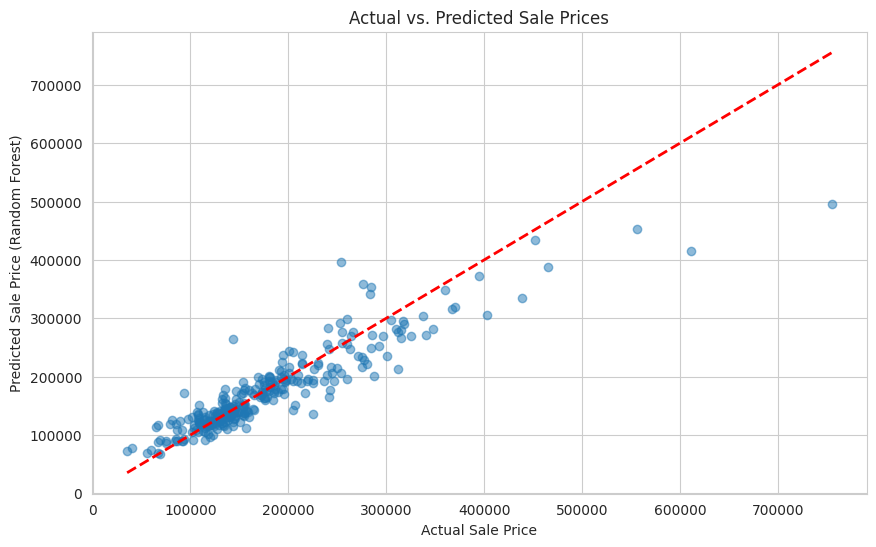

In [ ]:
# Optional: Visualize predictions vs actuals
plt.figure(figsize=(10, 6))
plt.scatter(np.expm1(y_test), y_pred_orig_best, alpha=0.5)
plt.plot([min(np.expm1(y_test)), max(np.expm1(y_test))], [min(np.expm1(y_test)), max(np.expm1(y_test))], '--', color='red', linewidth=2)
plt.xlabel('Actual Sale Price')
plt.ylabel(f'Predicted Sale Price ({best_model_name})')
plt.title('Actual vs. Predicted Sale Prices')
plt.gca().ticklabel_format(style='plain', axis='both') # Prevent scientific notation
plt.show()

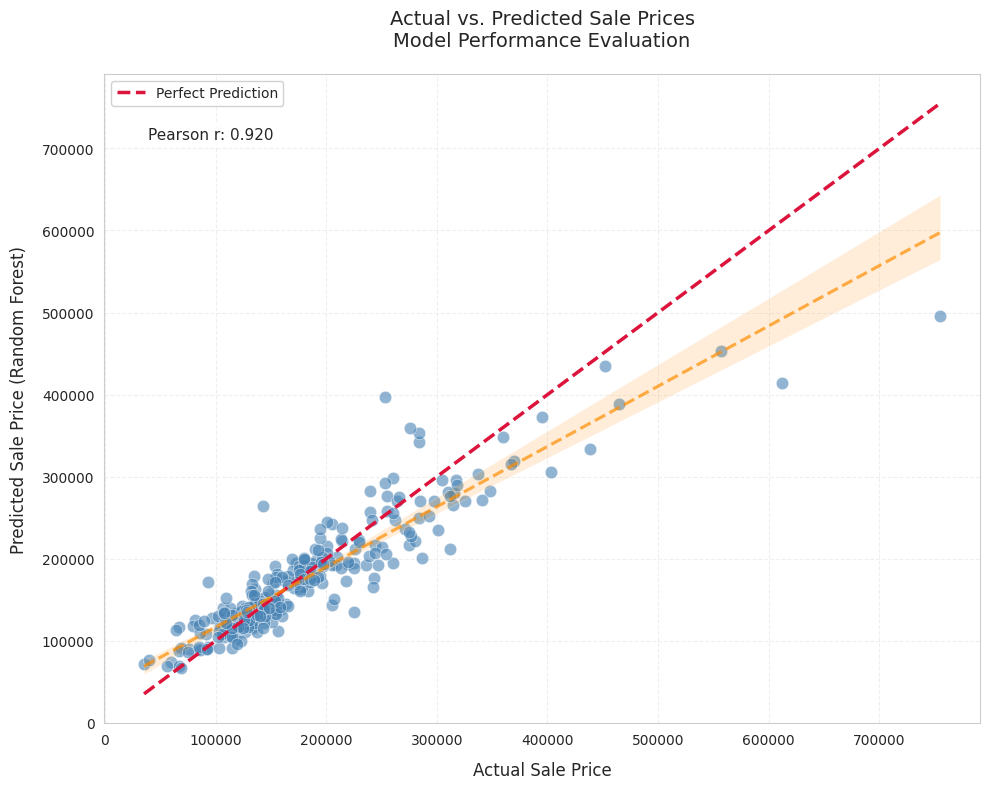

In [ ]:
plt.figure(figsize=(10, 8))  # Slightly taller figure for better proportions

# Convert to numpy arrays if they're pandas Series
y_test_values = np.expm1(y_test).values if hasattr(y_test, 'values') else np.expm1(y_test)
y_pred_values = y_pred_orig_best.values if hasattr(y_pred_orig_best, 'values') else y_pred_orig_best

# Create the scatter plot with improved parameters
scatter = plt.scatter(y_test_values, y_pred_values,
                     alpha=0.6,
                     c='steelblue',
                     edgecolor='white',
                     linewidth=0.5,
                     s=80)

# Perfect prediction line
min_val = min(np.min(y_test_values), np.min(y_pred_values))
max_val = max(np.max(y_test_values), np.max(y_pred_values))
plt.plot([min_val, max_val], [min_val, max_val],
         '--', color='crimson', linewidth=2.5,
         label='Perfect Prediction')

# Calculate and plot regression line
sns.regplot(x=y_test_values, y=y_pred_values,
            scatter=False,
            color='darkorange',
            line_kws={'linestyle': '--', 'alpha': 0.7, 'label': 'Trend Line'})

# Add labels and title with improved formatting
plt.xlabel('Actual Sale Price', fontsize=12, labelpad=10)
plt.ylabel(f'Predicted Sale Price ({best_model_name})', fontsize=12, labelpad=10)
plt.title('Actual vs. Predicted Sale Prices\nModel Performance Evaluation',
          fontsize=14, pad=20)

# Formatting improvements
plt.gca().ticklabel_format(style='plain', axis='both')
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(fontsize=10, framealpha=0.9)

# Add correlation coefficient annotation
corr = np.corrcoef(y_test_values, y_pred_values)[0, 1]
plt.annotate(f'Pearson r: {corr:.3f}',
             xy=(0.05, 0.9), xycoords='axes fraction',
             fontsize=11, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Adjust layout to prevent label cutoff
plt.tight_layout()
plt.show()